# Three classifier-guided conditional GANs

This notebook compares three classifier choices inside the same conditional GAN setup:

1. a small, deliberately simple CNN classifier trained from scratch,
2. the best **model type** from time-course classification, trained from scratch, and
3. the same best model loaded with its saved classification weights.

The saved validation-only ranking is read instead of hard-coding a winner. At the time this notebook was created, rank 1 was `extended_cnn_gated_fusion` (validation macro-F1 0.7161). GANs only see the fixed training fold; the test fold is opened after training for the final distribution comparison.

## Experimental design

All three runs use the same direct, dose-conditioned generator and the same binary real/fake critic. The only changed component is an auxiliary dose classifier. For a real batch the discriminator minimizes real/fake loss plus dose-classification loss. For a generated batch the generator minimizes real/fake loss plus the cross-entropy for the requested dose.

The pretrained classifier is **initialized** from the winning checkpoint and then fine-tuned under the same objective as the other two variants. Consequently, variants 2 and 3 isolate the effect of transferred weights, while variants 1 and 2 compare classifier capacity/inductive bias. Generator initialization, data order and latent-noise streams are reset to the same seed for every run.

In [1]:
from __future__ import annotations

import os
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from deeplearning_examples.io import load_data
from pytorch_cdgan.model import Discriminator, Generator, count_parameters, initialize_weights
from pytorch_timecourse_classification.artifacts import (
    artifact_dir_for,
    load_model,
    load_selection_manifest,
)
from pytorch_timecourse_classification.models import CNNClassifier, build_model

RANDOM_SEED = 32
NOISE_SIZE = 32
CONDITION_DIM = 3
# Override with GAN_EPOCHS=1 for a quick end-to-end smoke run.
EPOCHS = int(os.getenv("GAN_EPOCHS", "300"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={device}, epochs per variant={EPOCHS}")

device=cuda, epochs per variant=300


## 1. Resolve the best classifier without test leakage

In [2]:
selection = load_selection_manifest("extended_cnns_top3.json")
best_candidate = min(selection["candidates"], key=lambda row: row["rank"])
best_experiment = best_candidate["experiment"]
best_checkpoint_path = artifact_dir_for(best_experiment) / "model.pt"
pretrained_classifier, best_checkpoint = load_model(best_checkpoint_path, device="cpu")

assert selection["selection_fold"] == "validate"
assert best_checkpoint["model_name"] == "extended_cnn"
assert best_checkpoint["model_config"]["architecture"] == "gated_fusion"
print(pd.Series(best_candidate))
print(f"checkpoint: {best_checkpoint_path}")

rank                                               1
experiment                 extended_cnn_gated_fusion
accuracy                                    0.704871
balanced_accuracy                           0.742624
macro_precision                             0.722125
macro_recall                                0.742624
macro_f1                                     0.71613
weighted_f1                                 0.705843
mcc                                         0.651191
macro_roc_auc_ovr                            0.93726
macro_average_precision                     0.744037
log_loss                                    0.732617
brier_score                                 0.409066
dtype: object
checkpoint: /home/lorenz/Environments/DeeplearningExamples/projects/timecourse_classification/notebooks/artifacts/extended_cnn_gated_fusion/model.pt


## 2. Load train and validation data; keep test data untouched

The checkpoint's class order and train-derived normalization are authoritative for all auxiliary classifiers. Validation is used for the pre-training accuracy check. The test fold remains unopened until every GAN has finished training.

In [3]:
train_trajectories, train_doses, _ = load_data("train")
validation_trajectories, validation_doses, _ = load_data("validate")
dose_names = np.asarray(best_checkpoint["class_names"], dtype=object)
dose_to_id = {dose: index for index, dose in enumerate(dose_names)}
train_labels = np.asarray([dose_to_id[str(dose)] for dose in train_doses], dtype=np.int64)
validation_labels = np.asarray([dose_to_id[str(dose)] for dose in validation_doses], dtype=np.int64)
signal_mean = float(best_checkpoint["signal_mean"])
signal_std = float(best_checkpoint["signal_std"])

print(f"train: {train_trajectories.shape}; validation: {validation_trajectories.shape}")
print(dict(zip(dose_names, np.bincount(train_labels, minlength=len(dose_names)))))
assert train_trajectories.shape[1] == best_checkpoint["model_config"]["input_length"]
assert set(validation_doses) == set(dose_names)

train: (2790, 289); validation: (349, 289)
{'0pM': np.int64(286), '1pM': np.int64(621), '2.5pM': np.int64(533), '5pM': np.int64(487), '25pM': np.int64(581), '100pM': np.int64(282)}


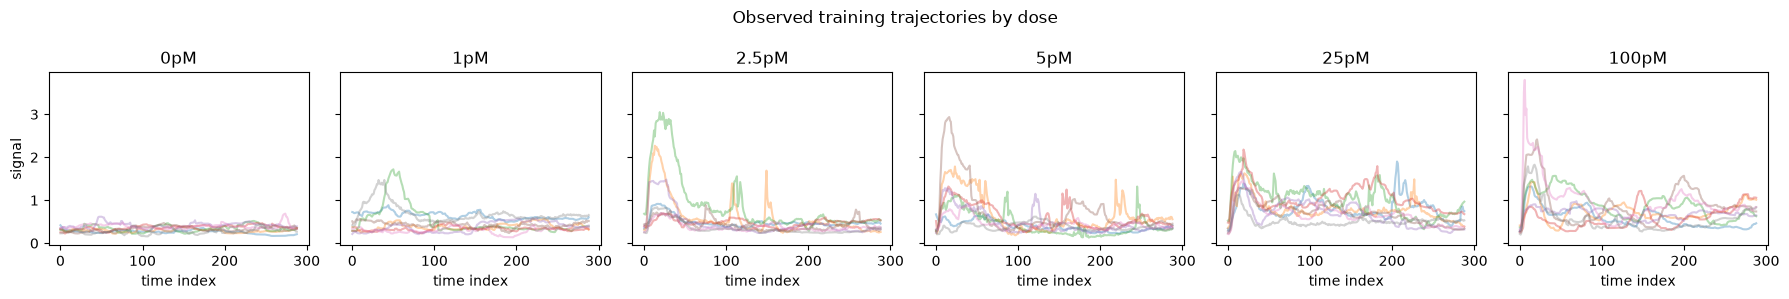

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
fig, axes = plt.subplots(1, len(dose_names), figsize=(18, 3), sharex=True, sharey=True)
for dose_id, (dose, axis) in enumerate(zip(dose_names, axes)):
    candidates = np.flatnonzero(train_labels == dose_id)
    chosen = rng.choice(candidates, min(8, len(candidates)), replace=False)
    axis.plot(train_trajectories[chosen].T, alpha=0.35)
    axis.set_title(str(dose))
    axis.set_xlabel("time index")
axes[0].set_ylabel("signal")
fig.suptitle("Observed training trajectories by dose")
fig.tight_layout()

## 3. Classifier-guided discriminator

The binary critic consumes raw trajectories and the requested dose condition. The auxiliary classifier consumes a z-scored trajectory because that is the representation used in time-course classification. The pretrained checkpoint is never reinitialized.

In [5]:
class ClassifierGuidedDiscriminator(nn.Module):
    def __init__(self, critic: nn.Module, classifier: nn.Module, mean: float, std: float) -> None:
        super().__init__()
        if std <= 0:
            raise ValueError("std must be positive")
        self.critic = critic
        self.classifier = classifier
        self.register_buffer("signal_mean", torch.tensor(mean, dtype=torch.float32))
        self.register_buffer("signal_std", torch.tensor(std, dtype=torch.float32))

    def critic_score(self, trajectories: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        return self.critic(trajectories, labels)

    def class_logits(self, trajectories: torch.Tensor) -> torch.Tensor:
        normalized = (trajectories - self.signal_mean) / self.signal_std
        return self.classifier(normalized)


def set_trainable(module: nn.Module, trainable: bool) -> None:
    for parameter in module.parameters():
        parameter.requires_grad_(trainable)

## 4. Common training loop

During a generator step discriminator parameters are frozen, but gradients still flow through both discriminator paths into the generated trajectory. Classification loss for discriminator updates is computed only on real samples, preventing the classifier from learning labels from early low-quality fakes. Generator-side classification guidance is ramped up over 50 epochs; this prevents the confident pretrained classifier from producing an overwhelmingly large loss on the initially random generator output.

In [6]:
@dataclass(frozen=True)
class GuidedGanConfig:
    epochs: int = 300
    batch_size: int = 256
    learning_rate: float = 1e-4
    classifier_weight: float = 0.5
    generator_classifier_warmup_epochs: int = 50
    report_every: int = 25
    random_seed: int = RANDOM_SEED


def train_guided_gan(generator, discriminator, trajectories, labels, *, config, device):
    torch.manual_seed(config.random_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(config.random_seed)
    features = torch.as_tensor(trajectories[:, None, :], dtype=torch.float32)
    targets = torch.as_tensor(labels, dtype=torch.long)
    loader = DataLoader(
        TensorDataset(features, targets),
        batch_size=config.batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(config.random_seed),
    )
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    generator_optimizer = torch.optim.Adam(generator.parameters(), lr=config.learning_rate, betas=(0.5, 0.999))
    discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=config.learning_rate, betas=(0.5, 0.999))
    adversarial_loss = nn.BCELoss()
    classification_loss = nn.CrossEntropyLoss()
    history = {name: [] for name in ("d_loss", "g_loss", "real_score", "fake_score", "real_class_accuracy")}

    for epoch in range(1, config.epochs + 1):
        totals = np.zeros(5, dtype=float)
        sample_count = 0
        for real_batch, label_batch in loader:
            real_batch = real_batch.to(device)
            label_batch = label_batch.to(device)
            batch_size = len(real_batch)
            real_targets = torch.ones((batch_size, 1), device=device)
            fake_targets = torch.zeros((batch_size, 1), device=device)

            set_trainable(discriminator, True)
            discriminator.train()
            discriminator_optimizer.zero_grad(set_to_none=True)
            real_score = discriminator.critic_score(real_batch, label_batch)
            real_logits = discriminator.class_logits(real_batch)
            with torch.no_grad():
                fake_batch = generator(torch.randn(batch_size, NOISE_SIZE, device=device), label_batch)
            fake_score = discriminator.critic_score(fake_batch, label_batch)
            d_loss = (
                adversarial_loss(real_score, real_targets)
                + adversarial_loss(fake_score, fake_targets)
                + config.classifier_weight * classification_loss(real_logits, label_batch)
            )
            d_loss.backward()
            discriminator_optimizer.step()

            set_trainable(discriminator, False)
            discriminator.eval()
            generator_optimizer.zero_grad(set_to_none=True)
            generated = generator(torch.randn(batch_size, NOISE_SIZE, device=device), label_batch)
            generated_score = discriminator.critic_score(generated, label_batch)
            generated_logits = discriminator.class_logits(generated)
            generator_classifier_weight = config.classifier_weight * min(
                1.0, epoch / max(config.generator_classifier_warmup_epochs, 1)
            )
            g_loss = (
                adversarial_loss(generated_score, real_targets)
                + generator_classifier_weight * classification_loss(generated_logits, label_batch)
            )
            g_loss.backward()
            generator_optimizer.step()

            batch_metrics = np.asarray([
                d_loss.item(), g_loss.item(), real_score.mean().item(), fake_score.mean().item(),
                (real_logits.argmax(dim=1) == label_batch).float().mean().item(),
            ])
            totals += batch_metrics * batch_size
            sample_count += batch_size

        set_trainable(discriminator, True)
        epoch_metrics = totals / sample_count
        for key, value in zip(history, epoch_metrics):
            history[key].append(float(value))
        if epoch == 1 or epoch % config.report_every == 0 or epoch == config.epochs:
            print(
                f"epoch {epoch:4d}: D={epoch_metrics[0]:.3f}, G={epoch_metrics[1]:.3f}, "
                f"D(real)={epoch_metrics[2]:.3f}, D(fake)={epoch_metrics[3]:.3f}, "
                f"class acc={epoch_metrics[4]:.3f}"
            )
    generator.eval()
    discriminator.eval()
    return generator, discriminator, history

## 5. Construct the three controlled variants

The scratch Gated-Fusion model uses the exact winning architecture and hyperparameters from the checkpoint. Loading the pretrained variant through `load_model` makes the transfer explicit and verifiable.

In [7]:
def make_simple_classifier():
    return CNNClassifier(
        input_length=train_trajectories.shape[1],
        num_classes=len(dose_names),
        channels=(16, 32),
        kernel_sizes=(9, 5),
        hidden_dim=32,
        dropout=0.2,
    )


def make_best_type_from_scratch():
    return build_model(best_checkpoint["model_name"], **best_checkpoint["model_config"])


def make_pretrained_best():
    model, checkpoint = load_model(best_checkpoint_path, device="cpu")
    assert checkpoint["best_epoch"] == best_checkpoint["best_epoch"]
    return model


classifier_factories = {
    "simple CNN": make_simple_classifier,
    "Gated Fusion: scratch": make_best_type_from_scratch,
    "Gated Fusion: pretrained": make_pretrained_best,
}
for name, factory in classifier_factories.items():
    model = factory()
    print(f"{name:27s} {count_parameters(model):>9,} classifier parameters")

simple CNN                      4,102 classifier parameters
Gated Fusion: scratch         463,366 classifier parameters
Gated Fusion: pretrained      463,366 classifier parameters


In [8]:
def classifier_accuracy(classifier, trajectories, labels):
    classifier = classifier.to(device).eval()
    normalized = torch.as_tensor(
        ((trajectories - signal_mean) / signal_std)[:, None, :],
        dtype=torch.float32,
        device=device,
    )
    with torch.no_grad():
        predictions = torch.cat([classifier(batch).argmax(1).cpu() for batch in normalized.split(256)])
    return float((predictions.numpy() == labels).mean())


initial_accuracy = {
    name: classifier_accuracy(factory(), validation_trajectories, validation_labels)
    for name, factory in classifier_factories.items()
}
pd.Series(initial_accuracy, name="validation accuracy before GAN training").to_frame().round(3)

,validation accuracy before GAN training
simple CNN,0.129
Gated Fusion: scratch,0.100
Gated Fusion: pretrained,0.705


## 6. Train all variants

Each run rebuilds generator and critic after resetting the seed. This keeps all non-classifier choices controlled. Full training uses 300 epochs per variant; set the environment variable `GAN_EPOCHS=1` before starting the kernel for a fast pipeline check.

In [9]:
trained = {}
config = GuidedGanConfig(epochs=EPOCHS)
for variant_name, classifier_factory in classifier_factories.items():
    print(f"\n--- {variant_name} ---")
    torch.manual_seed(RANDOM_SEED)
    generator = Generator(
        noise_size=NOISE_SIZE,
        output_length=train_trajectories.shape[1],
        num_conditions=len(dose_names),
        condition_dim=CONDITION_DIM,
    )
    critic = Discriminator(
        input_length=train_trajectories.shape[1],
        num_conditions=len(dose_names),
        condition_dim=CONDITION_DIM,
    )
    generator.apply(initialize_weights)
    critic.apply(initialize_weights)
    discriminator = ClassifierGuidedDiscriminator(
        critic, classifier_factory(), signal_mean, signal_std
    )
    trained[variant_name] = train_guided_gan(
        generator, discriminator, train_trajectories, train_labels,
        config=config, device=device,
    )


--- simple CNN ---
epoch    1: D=2.019, G=0.943, D(real)=0.655, D(fake)=0.456, class acc=0.131
epoch   25: D=1.617, G=1.988, D(real)=0.698, D(fake)=0.303, class acc=0.408
epoch   50: D=1.785, G=1.891, D(real)=0.614, D(fake)=0.393, class acc=0.437
epoch   75: D=1.841, G=1.751, D(real)=0.575, D(fake)=0.425, class acc=0.475
epoch  100: D=1.858, G=1.645, D(real)=0.561, D(fake)=0.440, class acc=0.471
epoch  125: D=1.885, G=1.470, D(real)=0.546, D(fake)=0.464, class acc=0.494
epoch  150: D=1.907, G=1.331, D(real)=0.529, D(fake)=0.480, class acc=0.501
epoch  175: D=1.894, G=1.283, D(real)=0.522, D(fake)=0.477, class acc=0.511
epoch  200: D=1.894, G=1.249, D(real)=0.517, D(fake)=0.474, class acc=0.503
epoch  225: D=1.897, G=1.208, D(real)=0.517, D(fake)=0.476, class acc=0.516
epoch  250: D=1.884, G=1.171, D(real)=0.523, D(fake)=0.480, class acc=0.528
epoch  275: D=1.882, G=1.135, D(real)=0.524, D(fake)=0.481, class acc=0.525
epoch  300: D=1.870, G=1.133, D(real)=0.526, D(fake)=0.476, class ac

### Open the held-out test fold after training

From this point onward the test fold is used only as a real-data reference for the final generative evaluation.

In [10]:
test_trajectories, test_doses, _ = load_data("test")
test_labels = np.asarray([dose_to_id[str(dose)] for dose in test_doses], dtype=np.int64)
test_dose_counts = np.bincount(test_labels, minlength=len(dose_names))
assert set(test_doses) == set(dose_names)
print(f"test: {test_trajectories.shape}; counts={dict(zip(dose_names, test_dose_counts))}")

test: (349, 289); counts={'0pM': np.int64(36), '1pM': np.int64(78), '2.5pM': np.int64(66), '5pM': np.int64(62), '25pM': np.int64(72), '100pM': np.int64(35)}


## 7. Training diagnostics

Adversarial losses and scores are optimization diagnostics, not sample-quality metrics. In particular, a critic score near 0.5 does not prove that the generated time courses have the correct biological distribution.

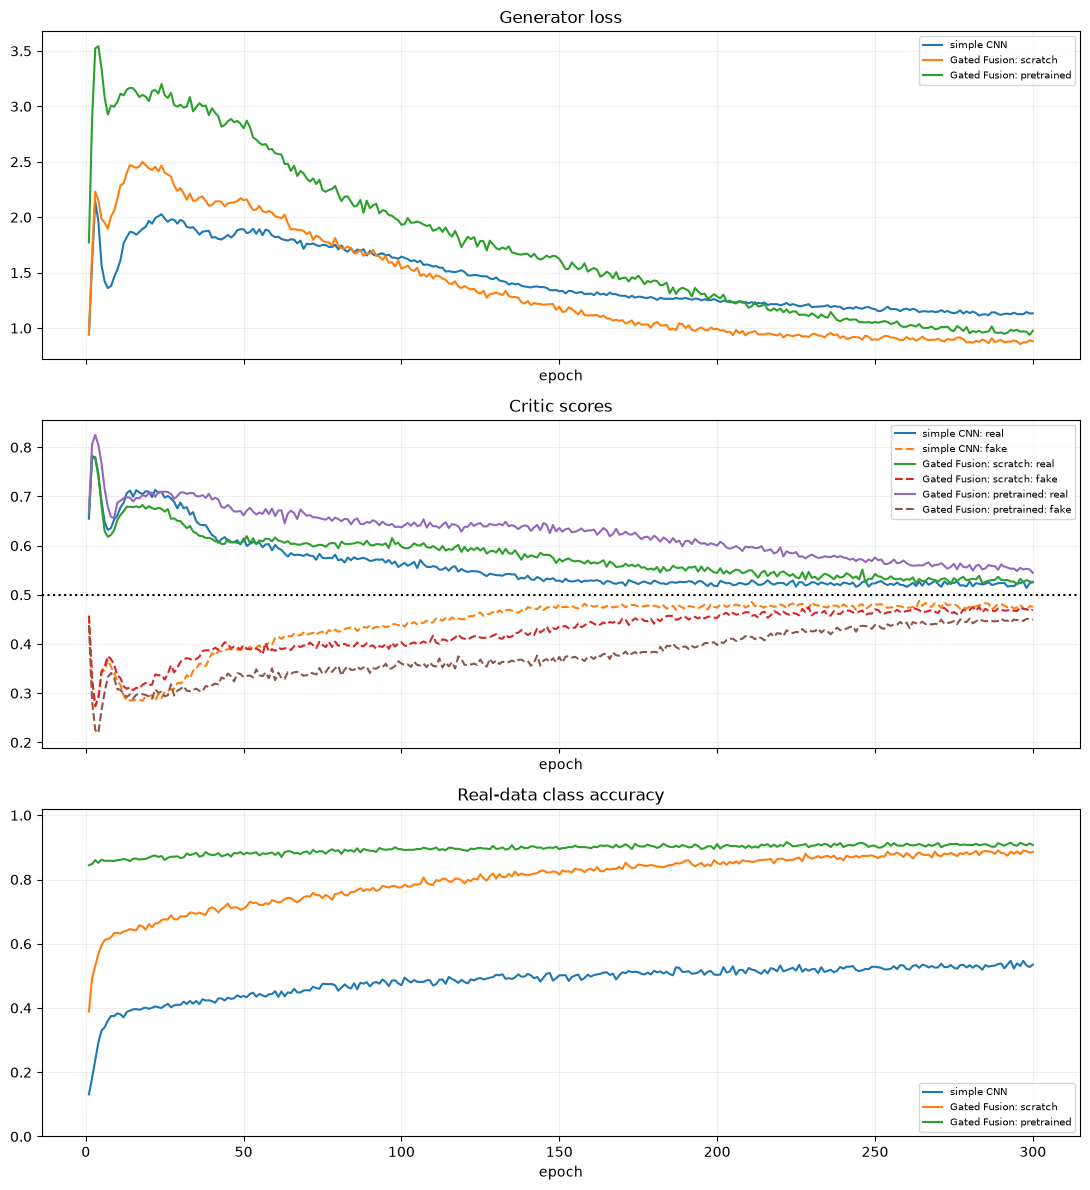

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)
for name, (_, _, history) in trained.items():
    epochs = np.arange(1, len(history["g_loss"]) + 1)
    axes[0].plot(epochs, history["g_loss"], label=name)
    axes[1].plot(epochs, history["real_score"], label=f"{name}: real")
    axes[1].plot(epochs, history["fake_score"], linestyle="--", label=f"{name}: fake")
    axes[2].plot(epochs, history["real_class_accuracy"], label=name)
axes[0].set(title="Generator loss", xlabel="epoch")
axes[1].axhline(0.5, color="black", linestyle=":")
axes[1].set(title="Critic scores", xlabel="epoch")
axes[2].set(title="Real-data class accuracy", xlabel="epoch", ylim=(0, 1.02))
for axis in axes:
    axis.grid(alpha=0.2)
    axis.legend(fontsize=7)
fig.tight_layout()

## 8. Generate a test-matched sample

For each dose, every generator produces exactly as many trajectories as exist in the untouched test fold. This avoids weighting dose-level summaries by different sample counts.

In [12]:
def sample_by_dose(model, counts, *, random_seed):
    model.eval()
    sample_generator = torch.Generator(device=device).manual_seed(random_seed)
    generated, labels = [], []
    with torch.no_grad():
        for dose_id, count in enumerate(counts):
            condition = torch.full((int(count),), dose_id, dtype=torch.long, device=device)
            noise = torch.randn(int(count), NOISE_SIZE, generator=sample_generator, device=device)
            generated.append(model(noise, condition).squeeze(1).cpu().numpy())
            labels.append(np.full(int(count), dose_id, dtype=np.int64))
    return np.concatenate(generated), np.concatenate(labels)


generated = {
    name: sample_by_dose(generator, test_dose_counts, random_seed=RANDOM_SEED + 1)
    for name, (generator, _, _) in trained.items()
}
{name: values[0].shape for name, values in generated.items()}

{'simple CNN': (349, 289),
 'Gated Fusion: scratch': (349, 289),
 'Gated Fusion: pretrained': (349, 289)}

In [13]:
FEATURES = (
    "mean signal",
    "temporal std",
    "maximum signal",
    "dynamic range",
    "endpoint change",
    "mean absolute step",
)


def trajectory_features(trajectories, labels):
    frame = pd.DataFrame({"dose_id": labels})
    frame["mean signal"] = trajectories.mean(axis=1)
    frame["temporal std"] = trajectories.std(axis=1)
    frame["maximum signal"] = trajectories.max(axis=1)
    frame["dynamic range"] = np.ptp(trajectories, axis=1)
    # Same definition as the existing data/GAN notebooks.
    frame["endpoint change"] = trajectories[:, -12:].mean(axis=1) - trajectories[:, :12].mean(axis=1)
    frame["mean absolute step"] = np.abs(np.diff(trajectories, axis=1)).mean(axis=1)
    return frame


feature_frames = {"test data": trajectory_features(test_trajectories, test_labels)}
feature_frames.update({name: trajectory_features(values, labels) for name, (values, labels) in generated.items()})

## 9. Median feature comparison across all six doses

This is the direct counterpart of the requested comparison plot. Markers are slightly offset only to keep overlapping values visible; every x-position still denotes the same dose.

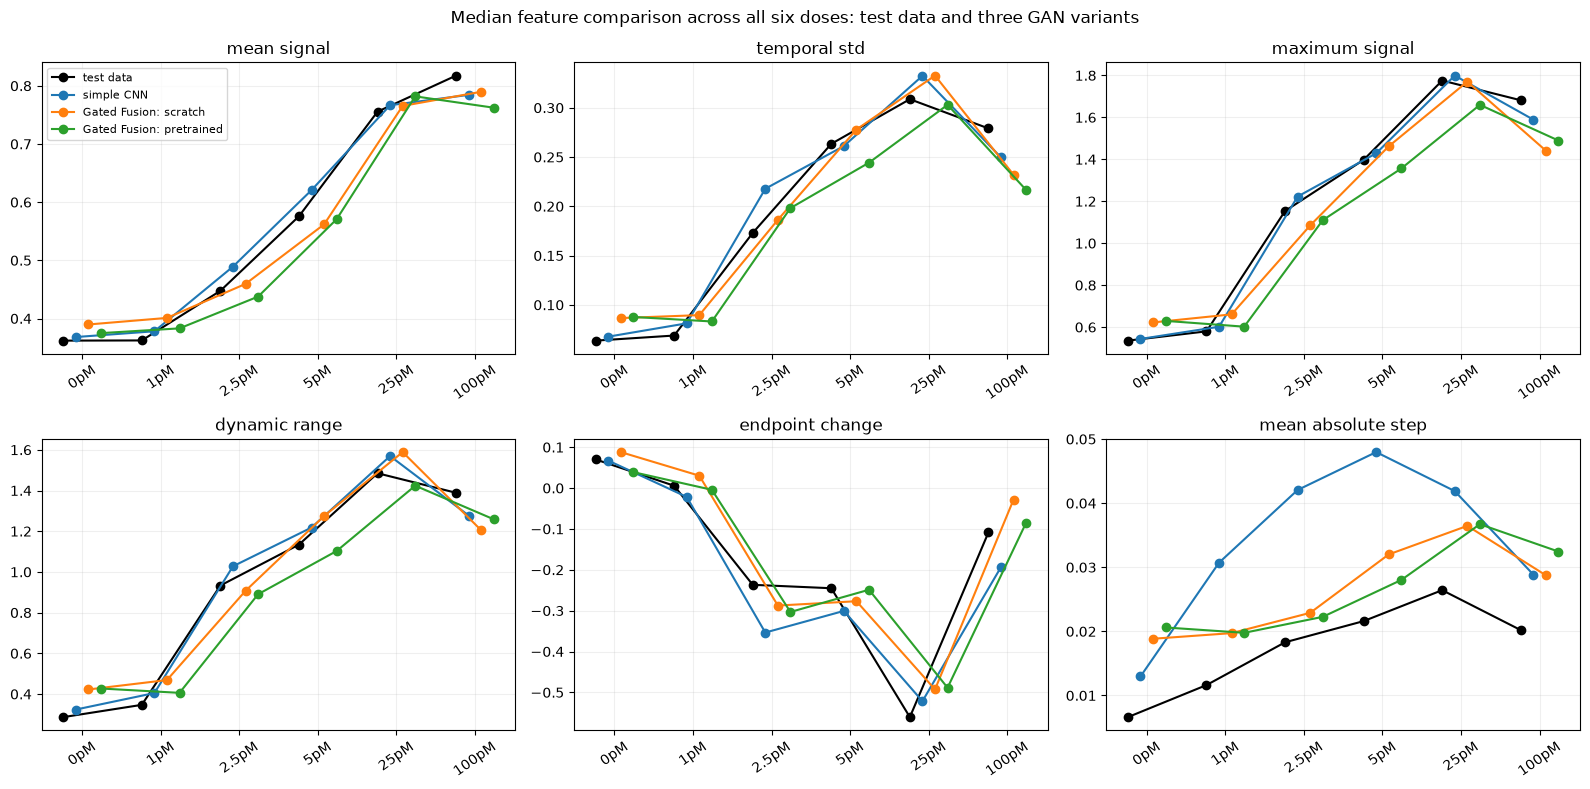

In [14]:
colors = ["black", "tab:blue", "tab:orange", "tab:green"]
offsets = np.linspace(-0.24, 0.24, len(feature_frames))
positions = np.arange(len(dose_names))
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for feature, axis in zip(FEATURES, axes.flat):
    for offset, (name, frame), color in zip(offsets, feature_frames.items(), colors):
        medians = frame.groupby("dose_id")[feature].median().reindex(range(len(dose_names)))
        axis.plot(positions + offset, medians, "o-", color=color, label=name)
    axis.set_title(feature)
    axis.set_xticks(positions, dose_names, rotation=35)
    axis.grid(alpha=0.2)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Median feature comparison across all six doses: test data and three GAN variants")
fig.tight_layout()

## 10. Quantitative comparison

For each feature, NMAE is the mean absolute difference between generated and real dose medians divided by the real median's range across doses. Lower is better. Dose fidelity is measured with a frozen, freshly reloaded copy of the winning classifier, so it is independent of the classifier that was fine-tuned inside each GAN.

In [15]:
def feature_nmae(real_frame, generated_frame, feature):
    real = real_frame.groupby("dose_id")[feature].median().reindex(range(len(dose_names))).to_numpy()
    fake = generated_frame.groupby("dose_id")[feature].median().reindex(range(len(dose_names))).to_numpy()
    scale = max(float(np.ptp(real)), np.finfo(float).eps)
    return float(np.mean(np.abs(fake - real)) / scale)


reference_classifier, _ = load_model(best_checkpoint_path, device=device)
reference_classifier.eval()
rows = []
for name, (samples, requested_labels) in generated.items():
    normalized = torch.as_tensor(
        ((samples - signal_mean) / signal_std)[:, None, :],
        dtype=torch.float32, device=device,
    )
    with torch.no_grad():
        predictions = torch.cat([reference_classifier(batch).argmax(1).cpu() for batch in normalized.split(256)]).numpy()
    row = {"variant": name, "dose fidelity": float(np.mean(predictions == requested_labels))}
    row.update({feature: feature_nmae(feature_frames["test data"], feature_frames[name], feature) for feature in FEATURES})
    row["mean feature NMAE"] = float(np.mean([row[feature] for feature in FEATURES]))
    rows.append(row)
comparison = pd.DataFrame(rows).set_index("variant").sort_values("mean feature NMAE")
comparison.round(3)

,dose fidelity,mean signal,temporal std,maximum signal,dynamic range,endpoint change,mean absolute step,mean feature NMAE
variant,,,,,,,,
Gated Fusion: pretrained,0.946,0.048,0.103,0.068,0.065,0.055,0.463,0.134
Gated Fusion: scratch,0.957,0.048,0.097,0.074,0.099,0.072,0.454,0.140
simple CNN,0.636,0.056,0.079,0.033,0.065,0.086,0.839,0.193


## 11. Dose-specific trajectory inspection

Feature summaries can hide mode collapse or implausible shapes. The following grid overlays test examples in light gray and generated examples in color for every dose and every variant.

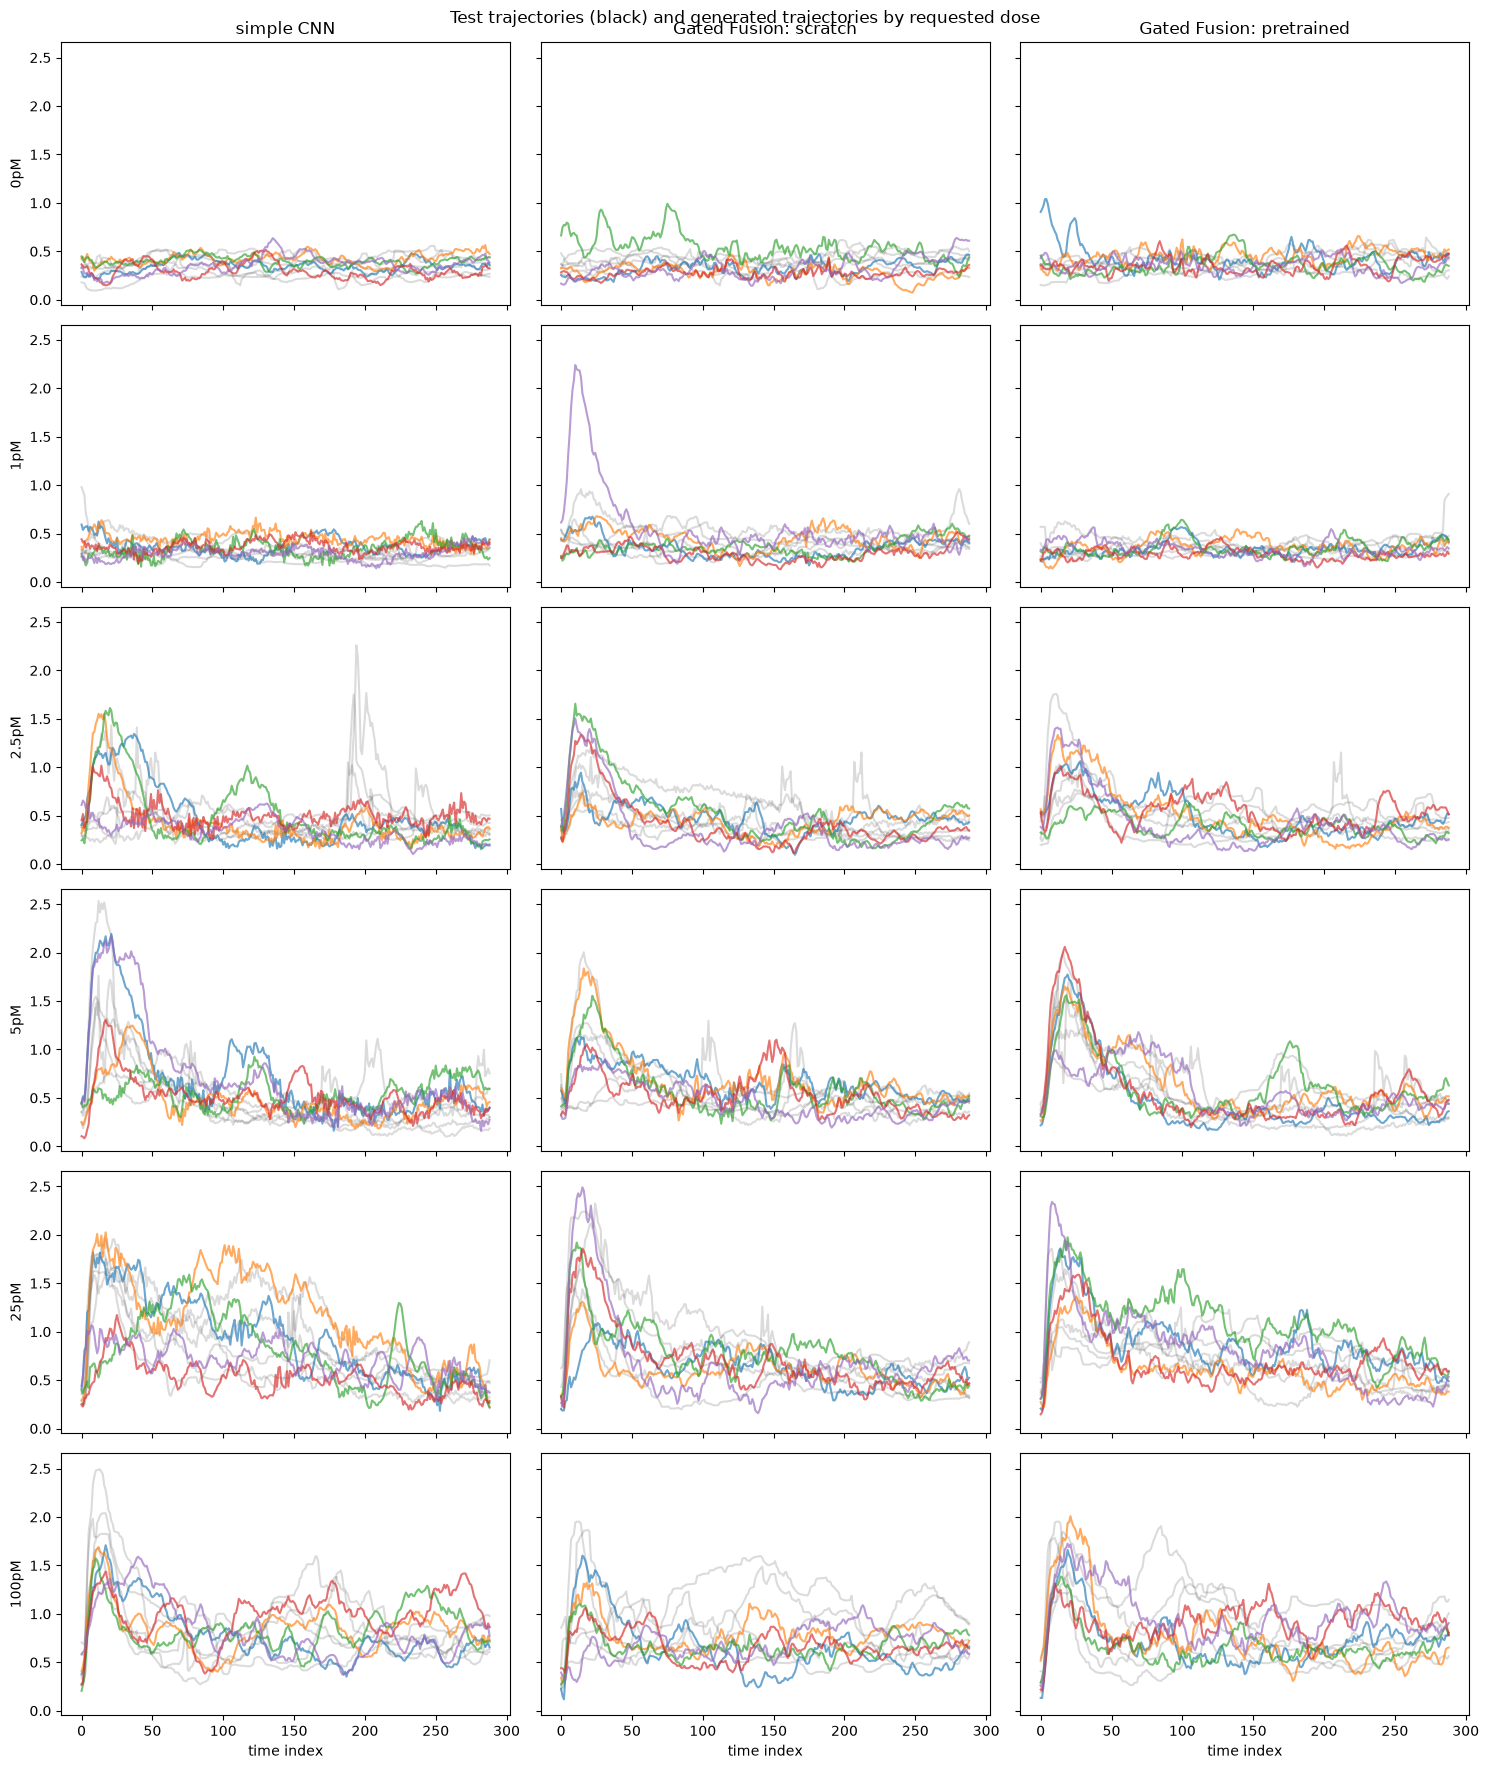

In [16]:
n_examples = 5
rng = np.random.default_rng(RANDOM_SEED + 2)
fig, axes = plt.subplots(len(dose_names), len(generated), figsize=(15, 18), sharex=True, sharey=True, squeeze=False)
for column, (name, (samples, sample_labels)) in enumerate(generated.items()):
    for dose_id, dose in enumerate(dose_names):
        axis = axes[dose_id, column]
        real_candidates = test_trajectories[test_labels == dose_id]
        fake_candidates = samples[sample_labels == dose_id]
        real_selection = rng.choice(len(real_candidates), min(n_examples, len(real_candidates)), replace=False)
        fake_selection = rng.choice(len(fake_candidates), min(n_examples, len(fake_candidates)), replace=False)
        axis.plot(real_candidates[real_selection].T, color="black", alpha=0.14)
        axis.plot(fake_candidates[fake_selection].T, alpha=0.65)
        if dose_id == 0:
            axis.set_title(name)
        if column == 0:
            axis.set_ylabel(str(dose))
        if dose_id == len(dose_names) - 1:
            axis.set_xlabel("time index")
fig.suptitle("Test trajectories (black) and generated trajectories by requested dose")
fig.tight_layout()

## Result-specific interpretation

Lowest held-out mean feature NMAE: Gated Fusion: pretrained (0.134).
Highest independent dose fidelity: Gated Fusion: scratch (0.957).
Transferred Gated-Fusion weights change mean feature NMAE by -0.007 and dose fidelity by -0.011 relative to the same architecture from scratch.
The final real/fake critic scores for the feature-NMAE winner are 0.545/0.450; these optimize adversarial separation but do not override the held-out feature and dose results above.

## Next experiment

Repeat all variants with several random seeds and report uncertainty before treating the single-seed ranking above as a model-selection result. Inspect the trajectory grid alongside the printed metrics to check whether the numerical winner has visibly collapsed to a small set of shapes.